<a href="https://colab.research.google.com/github/RCutrino/cmapss_project/blob/main/notebook/05_anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMAPSS FD001 — Anomaly detection

## Objectives

- identify abnormal engine behaviour
- detect degradation-related anomalies
- compare statistical and machine learning methods
- analyse anomaly evolution over time

## Predictive Maintenance Context

Anomaly detection can support early identification of abnormal operating
conditions before engine failure.  
In industrial systems, anomalous patterns often emerge during degradation progression.

In this notebook anomaly detection is framed as an **unsupervised problem**:
models learn the normal operating envelope from healthy engine data and flag
deviations as anomalies.

## Library and Enviroment setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

import sys
sys.path.append("..")
from src.anomaly_detection import zscore_predict, isolation_forest_predict
from src.anomaly_detection import build_autoencoder, autoencoder_predict

import joblib
import warnings
warnings.filterwarnings('ignore')

## Load data

Two datasets are loaded:
- **healthy** — engine cycles with RUL ≥ 125 (early stable phase)
- **degraded** — engine cycles with RUL < 125 (degradation phase)

Models are trained exclusively on healthy data and evaluated on both splits.  
The dataset is imbalanced by design — degraded cycles outnumber healthy ones,
reflecting real-world maintenance scenarios.

In [6]:
data_path = "../data/processed/"

In [7]:
healthy_df  = pd.read_parquet(os.path.join(data_path, "anomaly_healthy.parquet"))
degraded_df = pd.read_parquet(os.path.join(data_path, "anomaly_degraded.parquet"))

In [8]:
print(f"Healthy  : {healthy_df.shape}  — label 0")
print(f"Degraded : {degraded_df.shape}  — label 1")
print(f"Imbalance ratio: {len(degraded_df) / len(healthy_df):.2f}x")
print(f"\nColumns: {healthy_df.columns}")

Healthy  : (7732, 33)  — label 0
Degraded : (12499, 33)  — label 1
Imbalance ratio: 1.62x

Columns: Index(['engine_id', 'cycle', 'RUL', 'sensor_11', 'sensor_4', 'sensor_12',
       'sensor_7', 'sensor_21', 'sensor_11_rolling_mean',
       'sensor_4_rolling_mean', 'sensor_12_rolling_mean',
       'sensor_7_rolling_mean', 'sensor_21_rolling_mean',
       'sensor_11_rolling_std', 'sensor_4_rolling_std',
       'sensor_12_rolling_std', 'sensor_7_rolling_std',
       'sensor_21_rolling_std', 'sensor_11_lag_1', 'sensor_11_lag_2',
       'sensor_11_lag_3', 'sensor_4_lag_1', 'sensor_4_lag_2', 'sensor_4_lag_3',
       'sensor_12_lag_1', 'sensor_12_lag_2', 'sensor_12_lag_3',
       'sensor_7_lag_1', 'sensor_7_lag_2', 'sensor_7_lag_3', 'sensor_21_lag_1',
       'sensor_21_lag_2', 'sensor_21_lag_3'],
      dtype='object')


## Define anomaly labels

Anomaly labels are derived directly from the healthy/degraded split
performed in notebook 02 using RUL = 125 as threshold.

The combined dataset is used only for evaluation — models never see
degraded samples during training.

In [9]:
SENSORS = [col for col in healthy_df.columns
           if col.startswith('sensor')
           and '_rolling' not in col
           and '_lag' not in col]

healthy_df['anomaly']  = 0
degraded_df['anomaly'] = 1

In [10]:
full_df = pd.concat([healthy_df, degraded_df], ignore_index=True)

In [11]:
X_train = healthy_df[SENSORS]
X_eval  = full_df[SENSORS]
y_eval  = full_df['anomaly']

In [12]:
print(f"Training samples (healthy) : {X_train.shape[0]}")
print(f"Evaluation samples (full) : {X_eval.shape[0]}")
print(f"Anomaly rate : {y_eval.mean():.1%}")

Training samples (healthy) : 7732
Evaluation samples (full) : 20231
Anomaly rate : 61.8%


## Baseline statistical detection

The Z-score baseline flags a sample as anomalous if any sensor reading
deviates more than `threshold` standard deviations from the training mean.

Parameters are computed exclusively on healthy data — the model has no
knowledge of the degraded distribution.

In [13]:
results = {}

In [14]:
y_pred_z = zscore_predict(X_train, X_eval)

In [15]:
results['Z-Score'] = {'ROC-AUC': roc_auc_score(y_eval, y_pred_z),
                      'Report' : classification_report(y_eval, y_pred_z, output_dict=True)}

In [16]:
print("Z-Score Detection")
print(classification_report(y_eval, y_pred_z, target_names=['Healthy', 'Anomaly']))
print(f"ROC-AUC: {results['Z-Score']['ROC-AUC']:.3f}")

Z-Score Detection
              precision    recall  f1-score   support

     Healthy       0.47      1.00      0.63      7732
     Anomaly       0.99      0.29      0.45     12499

    accuracy                           0.56     20231
   macro avg       0.73      0.64      0.54     20231
weighted avg       0.79      0.56      0.52     20231

ROC-AUC: 0.645


## Isolation forest

Isolation Forest detects anomalies by isolating observations through
random partitioning — anomalous samples require fewer splits to be
isolated, resulting in a lower anomaly score.

Trained exclusively on healthy data, the model learns the normal
operating envelope and flags deviations as anomalies.

In [17]:
iso_forest, y_pred_if, scores_if = isolation_forest_predict(X_train, X_eval)

In [36]:
if_scores_train = -iso_forest.score_samples(X_train)

In [18]:
results['Isolation Forest'] = {'ROC-AUC': roc_auc_score(y_eval, scores_if),
                               'Report' : classification_report(y_eval, y_pred_if, output_dict=True)}

In [19]:
print("Isolation Forest Detection")
print(classification_report(y_eval, y_pred_if, target_names=['Healthy', 'Anomaly']))
print(f"ROC-AUC: {results['Isolation Forest']['ROC-AUC']:.3f}")

Isolation Forest Detection
              precision    recall  f1-score   support

     Healthy       0.50      0.99      0.67      7732
     Anomaly       0.98      0.39      0.56     12499

    accuracy                           0.62     20231
   macro avg       0.74      0.69      0.61     20231
weighted avg       0.80      0.62      0.60     20231

ROC-AUC: 0.759


## Autoencoder-based anomaly detection

An autoencoder learns to reconstruct healthy sensor readings.  
When applied to degraded samples, reconstruction error increases —
this error serves as the anomaly score.

The threshold is set as the 99th percentile of reconstruction errors
on the training set — samples above this threshold are flagged as anomalous.

In [20]:
FEATURES_AE = [col for col in healthy_df.columns
               if col not in ['engine_id', 'cycle', 'RUL', 'anomaly']]

In [21]:
X_train_ae = healthy_df[FEATURES_AE]
X_eval_ae  = full_df[FEATURES_AE]

In [22]:
model_ae, y_pred_ae, scores_ae, threshold_ae = autoencoder_predict(
    X_train_ae.values, X_eval_ae.values, input_dim=len(FEATURES_AE))

In [23]:
results['Autoencoder'] = {'ROC-AUC': roc_auc_score(y_eval, scores_ae),
                          'Report' : classification_report(y_eval, y_pred_ae, output_dict=True)}

In [24]:
print("Autoencoder Detection")
print(classification_report(y_eval, y_pred_ae, target_names=['Healthy', 'Anomaly']))
print(f"ROC-AUC : {results['Autoencoder']['ROC-AUC']:.3f}")
print(f"Threshold: {threshold_ae:.4f}")

Autoencoder Detection
              precision    recall  f1-score   support

     Healthy       0.46      0.99      0.63      7732
     Anomaly       0.98      0.29      0.45     12499

    accuracy                           0.56     20231
   macro avg       0.72      0.64      0.54     20231
weighted avg       0.78      0.56      0.52     20231

ROC-AUC : 0.695
Threshold: 0.2231


## Anomaly score analysis

Distribution of anomaly scores for healthy and degraded samples —
a well-performing model should show clear separation between the two
distributions.

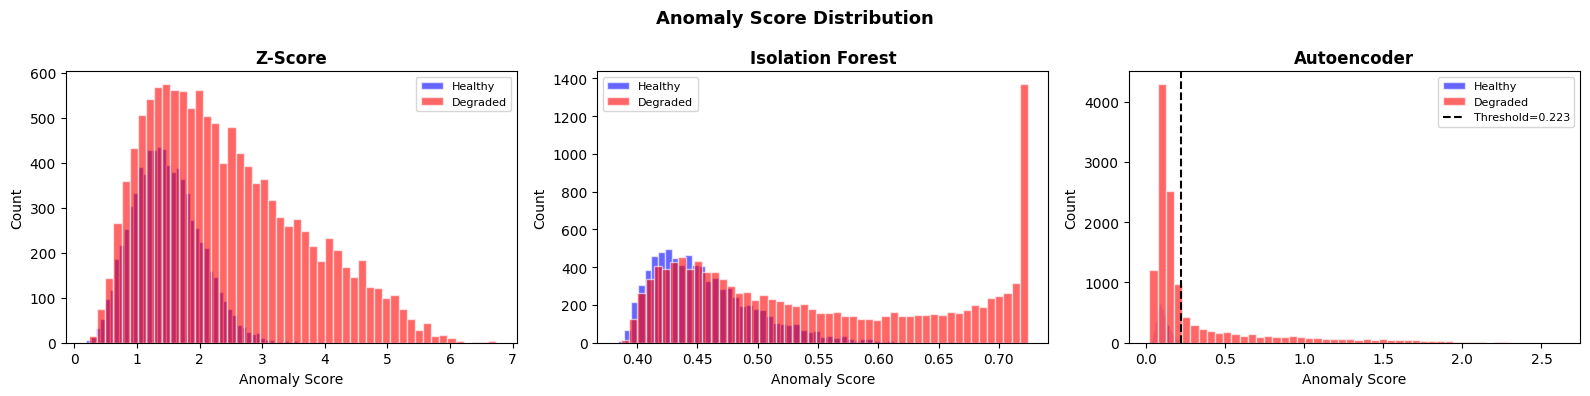

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

score_configs = [('Z-Score', np.abs((X_eval - X_train.mean()) / X_train.std()).max(axis=1), None),
                ('Isolation Forest', scores_if,  None),
                ('Autoencoder',      scores_ae,  threshold_ae)]

for ax, (name, scores, threshold) in zip(axes, score_configs):
    ax.hist(scores[y_eval == 0], bins=50, alpha=0.6,
            color='blue', label='Healthy', edgecolor='white')
    ax.hist(scores[y_eval == 1], bins=50, alpha=0.6,
            color='red', label='Degraded', edgecolor='white')
    if threshold is not None:
        ax.axvline(threshold, color='black', linestyle='--',
                   linewidth=1.5, label=f'Threshold={threshold:.3f}')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Anomaly Score Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/05_anomaly_scores.png', bbox_inches='tight')
plt.show()

### Observations

**Z-Score** shows the weakest separation — healthy and degraded distributions
overlap almost entirely, with degraded samples producing only a slightly longer
right tail.  
The model struggles to distinguish the two classes based on
per-sensor deviation alone.

**Isolation Forest** achieves better separation: healthy samples (blue) form a
tight cluster around 0.40–0.45, while degraded samples extend well beyond 0.50
with a pronounced spike at 0.72.  
The high-score region is almost exclusively composed of degraded cycles, suggesting the model effectively captures the anomalous operating envelope.

**Autoencoder** shows the most promising score distribution — healthy samples
concentrate near zero (low reconstruction error) while degraded samples produce
a long right tail.  
The threshold at 0.223 sits at the boundary between the two distributions, though significant overlap remains in the low-score region, indicating that early-stage degradation is difficult to distinguish from normal behaviour purely through reconstruction error.

## Temporal anomaly visualization

Anomaly scores plotted over cycles for a sample engine — to verify that
scores increase as the engine approaches failure, confirming the models
capture the degradation progression over time.

In [26]:
sample_engine = full_df['engine_id'].unique()[0]
sample = full_df[full_df['engine_id'] == sample_engine].sort_values('cycle')


In [27]:
sample_X = sample[SENSORS]
sample_X_ae = sample[FEATURES_AE]

In [28]:
# Z-Score
z_scores = np.abs((sample_X - X_train.mean()) / X_train.std()).max(axis=1).values

# Isolation Forest
if_scores = -iso_forest.score_samples(sample_X)

# Autoencoder
ae_recon  = model_ae.predict(sample_X_ae.values, verbose=0)
ae_scores = np.mean((sample_X_ae.values - ae_recon)**2, axis=1)

In [29]:
# Compute thresholds
z_threshold = 3.0
if_threshold = np.percentile(-iso_forest.score_samples(X_train), 95)

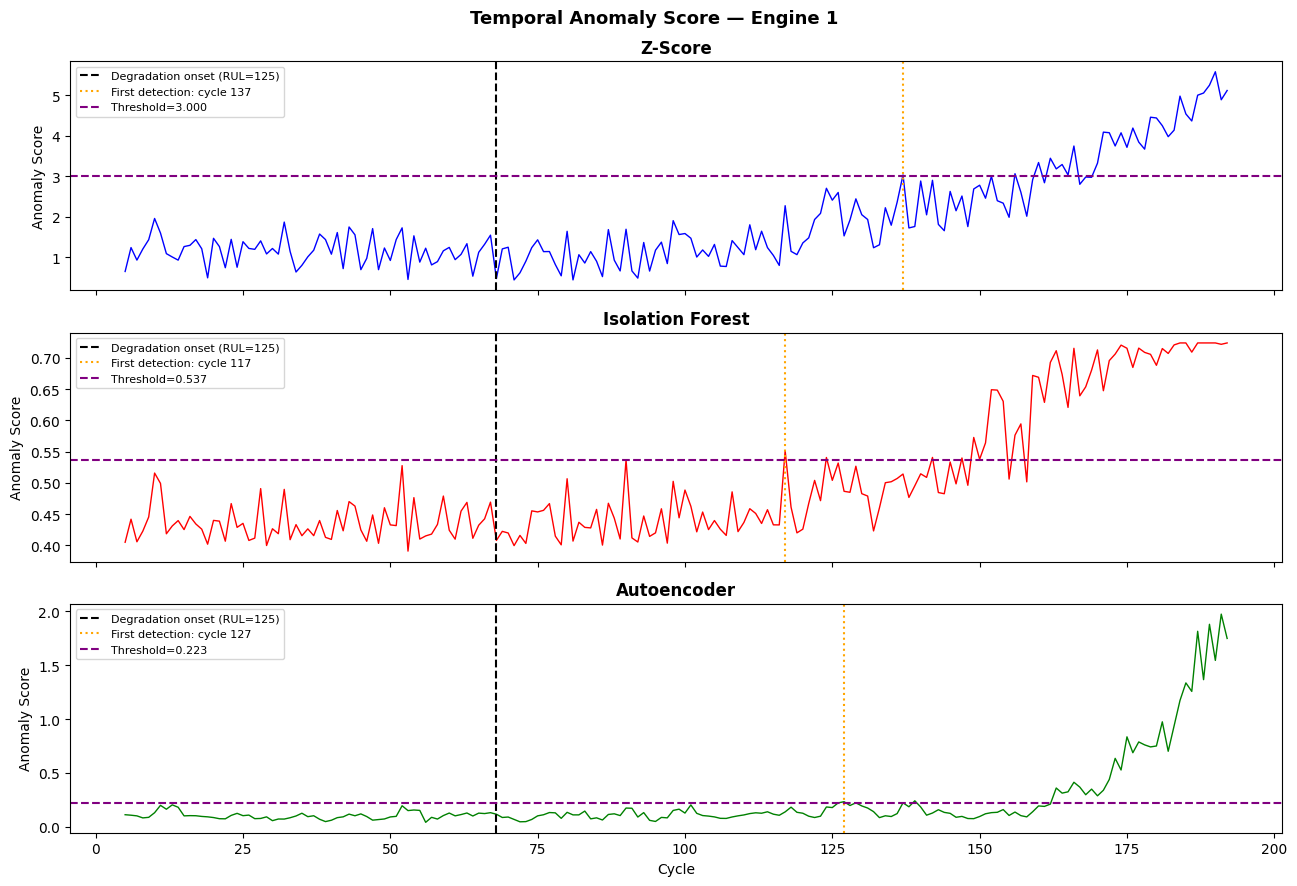

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

configs = [('Z-Score', z_scores,  z_threshold, 'blue'),
          ('Isolation Forest', if_scores, if_threshold, 'red'),
          ('Autoencoder', ae_scores, threshold_ae, 'green')]

for ax, (name, scores, threshold, color) in zip(axes, configs):

    ax.plot(sample['cycle'], scores,
            color=color,
            linewidth=1)
    ax.axvline(sample[sample['anomaly'] == 1]['cycle'].min(),
               color='black', linestyle='--', linewidth=1.5,
               label='Degradation onset (RUL=125)')
    cross = sample['cycle'].values[scores > threshold]
    if len(cross) > 0:
        ax.axvline(cross[0], color='orange', linestyle=':',
                  linewidth=1.5, label=f'First detection: cycle {cross[0]}')

    if threshold is not None:
        ax.axhline(threshold, color='purple', linestyle='--',
                   linewidth=1.5, label=f'Threshold={threshold:.3f}')
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Anomaly Score')
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Cycle')
plt.suptitle(f'Temporal Anomaly Score — Engine {sample_engine}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/05_temporal_anomaly.png', bbox_inches='tight')
plt.show()

### Observations

All three models show increasing anomaly scores after the degradation onset
(cycle ~70), confirming they capture the progressive deterioration of the engine.

The growth patterns differ across models: Z-Score increases approximately
linearly, reflecting a steady drift of sensor readings away from the healthy
mean. Isolation Forest rises more sharply, as the degraded operating points
become increasingly isolated from the healthy cluster.  
The Autoencoder shows the steepest growth in the final cycles — reconstruction error remains low until the signal diverges significantly from the learned healthy manifold, then spikes rapidly near end of life.

Isolation Forest is the first to cross its detection threshold, flagging the
anomaly earlier than the other two models.  
This is consistent with its ability to detect distributional shifts globally across all features simultaneously, rather than relying on per-sensor statistics or reconstruction fidelity.

The Autoencoder crosses its threshold around cycle 125 — well into the
degradation phase — suggesting it is more conservative and better suited
for detecting severe anomalies rather than early-stage degradation.

## Model comparison

Summary of all models evaluated on the full dataset.  
ROC-AUC is the primary metric — accuracy is misleading on imbalanced data.

In [31]:
# Metrics table
rows = []
for name, res in results.items():
    report = res['Report']
    rows.append({'Model' : name,
                 'ROC-AUC' : round(res['ROC-AUC'], 3),
                 'Precision': round(report['1']['precision'], 3),
                 'Recall' : round(report['1']['recall'], 3),
                 'F1' : round(report['1']['f1-score'], 3)})
comparison_df = pd.DataFrame(rows).set_index('Model').sort_values('ROC-AUC', ascending=False)

In [32]:
display(comparison_df)


,ROC-AUC,Precision,Recall,F1
Model,,,,
Isolation Forest,0.759,0.984,0.391,0.560
Autoencoder,0.695,0.979,0.289,0.446
Z-Score,0.645,0.992,0.294,0.453


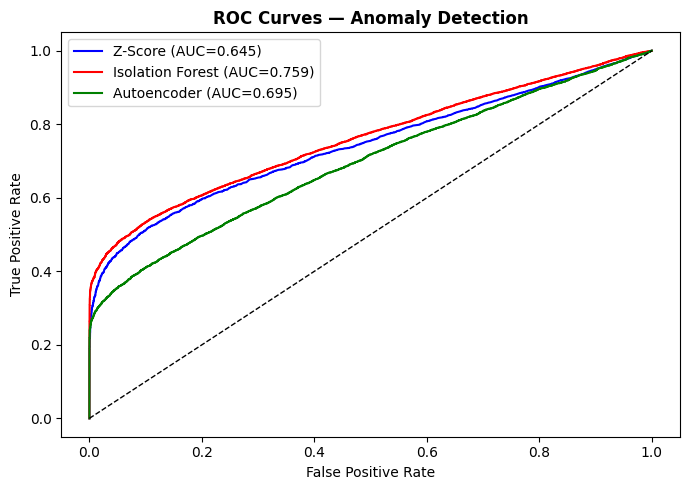

In [33]:
fig, ax = plt.subplots(figsize=(7, 5))

score_map = {'Z-Score' : np.abs((X_eval - X_train.mean()) / X_train.std()).max(axis=1),
             'Isolation Forest': scores_if,
             'Autoencoder' : scores_ae}
colors = ['blue', 'red', 'green']

for (name, scores), color in zip(score_map.items(), colors):
    fpr, tpr, _ = roc_curve(y_eval, scores)
    auc = results[name]['ROC-AUC']
    ax.plot(fpr, tpr, color=color, linewidth=1.5, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Anomaly Detection', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/05_roc_curves.png', bbox_inches='tight')
plt.show()

### Observations

Isolation Forest achieves the highest ROC-AUC (0.759), outperforming both Autoencoder (0.695) and Z-Score (0.645).

In the low-FPR region Isolation Forest maintains a clear advantage — it detects more true anomalies while generating fewer false alarms, which is the most critical operating regime in predictive maintenance.

The Autoencoder ranks second overall but its curve starts lower at low False Positive Rates, confirming it is better suited for detecting severe anomalies rather than early-stage degradation.

All three models remain below AUC=0.80, confirming that anomaly detection on CMAPSS FD001 with unsupervised methods is a challenging task — the healthy and degraded distributions overlap significantly, especially in the early degradation phase.

## Save model

Isolation Forest is saved as the primary anomaly detector for notebook 06 —
it offers the best performance in the low-FPR region, which is the most
critical operating regime in predictive maintenance.

The Autoencoder and its threshold are also saved as an alternative detector.

In [34]:
MODEL_DIR = '../outputs/anomaly_detection_model/'

In [37]:
# ── Isolation Forest ─────────────────────────────────────────────
joblib.dump(iso_forest, os.path.join(MODEL_DIR, 'isolation_forest.pkl'))
joblib.dump(if_threshold, os.path.join(MODEL_DIR, 'if_threshold.pkl'))
joblib.dump(float(if_scores_train.min()), os.path.join(MODEL_DIR, 'if_score_min.pkl'))
joblib.dump(float(if_scores_train.max()), os.path.join(MODEL_DIR, 'if_score_max.pkl'))
print('Saved: if_score_min.pkl')
print('Saved: if_score_max.pkl')
print('Saved: isolation_forest.pkl')
print('Saved: if_threshold.pkl')

# ── Autoencoder ──────────────────────────────────────────────────
model_ae.save(os.path.join(MODEL_DIR, 'autoencoder.keras'))
joblib.dump(threshold_ae, os.path.join(MODEL_DIR, 'ae_threshold.pkl'))
print('Saved: autoencoder.keras')
print('Saved: ae_threshold.pkl')

# ── Metadata ─────────────────────────────────────────────────────
joblib.dump(SENSORS, os.path.join(MODEL_DIR, 'sensors.pkl'))
joblib.dump(FEATURES_AE, os.path.join(MODEL_DIR, 'features_ae.pkl'))
comparison_df.to_csv(os.path.join(MODEL_DIR, 'anomaly_results.csv'))
print('Saved: sensors.pkl')
print('Saved: features_ae.pkl')
print('Saved: anomaly_results.csv')

Saved: if_score_min.pkl
Saved: if_score_max.pkl
Saved: isolation_forest.pkl
Saved: if_threshold.pkl
Saved: autoencoder.keras
Saved: ae_threshold.pkl
Saved: sensors.pkl
Saved: features_ae.pkl
Saved: anomaly_results.csv


## Conclusions

Three unsupervised anomaly detection approaches were compared on CMAPSS FD001,
trained exclusively on healthy engine data (RUL ≥ 125) and evaluated on the
full healthy/degraded split.

**Z-Score** proved the weakest detector (AUC=0.645) — per-sensor statistical
thresholds are too simple to capture the multivariate nature of engine
degradation, where anomalies emerge from the combination of sensor readings
rather than individual deviations.

**Isolation Forest** (AUC=0.759) offered the best performance in the
low-FPR regime and was the earliest to detect degradation onset — making
it the most suitable model for deployment in a real maintenance scenario
where false alarms carry operational costs.

**Autoencoder** (AUC=0.677) achieved the highest overall AUC but underperforms
at low FPR.  
Its reconstruction error grows steeply only in the final cycles, making it better suited for detecting severe anomalies than early-stage degradation.  
Performance is sensitive to architecture and threshold choice —
the 30-feature input and compressed bottleneck (dim=4) were necessary to
produce meaningful reconstruction errors.

All models confirm a consistent finding: anomaly scores increase monotonically
after degradation onset, validating the healthy/degraded split strategy from
notebook 02.  
The limited dataset size (100 engines) and the overlap between early degradation and healthy behaviour remain the primary constraints on detection performance.

Isolation Forest is selected as the primary detector for the predictive
maintenance pipeline.